In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf

# Keep routine progress messages out of the teaching output.
scarf.configure_output(level="WARNING", progress=False)

# Download the prepared example, including its saved analysis.
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq", destination="scarf_datasets", zarr=True
)

Downloading bucket files: 56215324 / 56215324 complete

Downloading bytes: 56215324 / 56215324 complete

In [2]:
# Open the datastore for the following analysis.
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
# Open the saved analysis and retain its exact results.
run = ds.pipeline.open(label="docs_default")
# Keep the graph used by the saved analysis.
graph = run["connectivity_map"]
# Reuse the saved UMAP coordinates.
umap = run["umap"]
# Reuse the 15-cluster Paris cut of this graph.
paris = ds.run_paris_clustering(graph, n_clusters=15)
# Inspect the opened assays and their dimensions.
ds

DataStore has 3948 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_G2M_score', 'RNA_S_score', 
            'RNA_UMAP1', 'RNA_UMAP2', 'RNA_cell_cycle_phase', 'RNA_clusters', 'RNA_doublet_score', 
            'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_paris_cluster', 'RNA_percentMito', 
            'RNA_percentRibo'
   RNA assay has 33538 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'feature_type', 
            'genome', 'nCells'

In [3]:
# Load the Paris labels and hierarchy diagnostics.
paris_result = ds.load_paris_clustering(paris)
# Count cells in the 15 Paris groups used for sampling.
cluster_counts = pd.Series(paris_result.labels, name="cluster").value_counts()
# Inspect group sizes in cluster-label order.
cluster_counts.sort_index().to_frame("cells")

,cells
cluster,
1,772
2,567
3,381
4,332
5,332
6,310
7,284
8,260
9,247


In [4]:
# Select representative cells from the graph and Paris cut.
sampling = ds.run_topacedo_sampler(graph, paris)
# Open the saved sampling result.
sampling_data = ds.load_artifact(sampling)
# Read the sampling mask in the graph's cell order.
sampled = np.asarray(sampling_data["sampled"][:], dtype=bool)
# Compare the sampled-cell count with the full graph size.
{"cells": int(sampled.size), "selected": int(sampled.sum())}

INFO: 244 cells (6.18%) sub-sampled. Subsample to Seed (85 cells) ratio: 2.871


Constructing graph from dendrogram: 3947 / 3947 complete

{'cells': 3948, 'selected': 244}

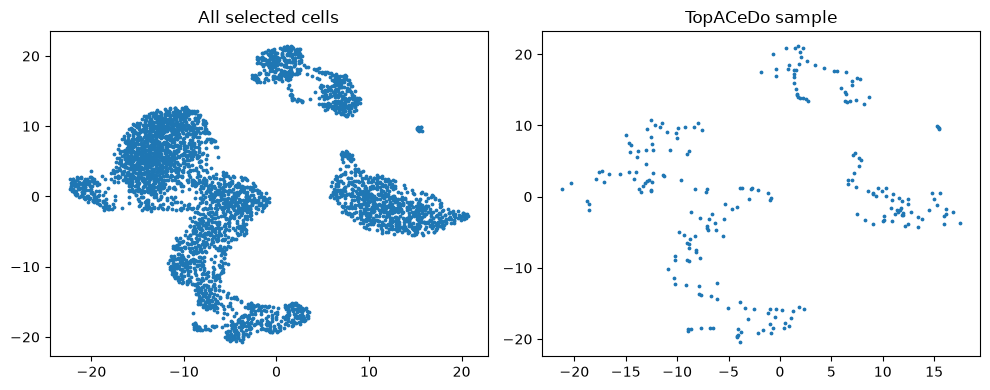

In [5]:
# Read the saved embedding in that same order.
coordinates = np.asarray(ds.load_artifact(umap)["values"][:])
# Create one plotting axis for each comparison panel.
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
# Plot these cells using the selected coordinates and values.
axes[0].scatter(coordinates[:, 0], coordinates[:, 1], s=3)
# Label the panel with the quantity being compared.
axes[0].set_title("All selected cells")
# Plot these cells using the selected coordinates and values.
axes[1].scatter(coordinates[sampled, 0], coordinates[sampled, 1], s=3)
# Label the panel with the quantity being compared.
axes[1].set_title("TopACeDo sample")
# Adjust spacing so panel labels remain readable.
figure.tight_layout()

In [6]:
# Locate graph cells on the original metadata axis.
graph_cell_indices = np.flatnonzero(run.cells.fetch_all("I"))
# Map the sampling mask back to physical cell rows.
sampled_cell_indices = graph_cell_indices[sampled]

# Check how many physical cell rows will be exported.
{"cells to export": len(sampled_cell_indices)}

{'cells to export': 244}

In [7]:
# Keep the exported example in a temporary folder.
export_directory = TemporaryDirectory()
# Choose a new path for the selected-cell store.
subset_path = Path(export_directory.name) / "subset.zarr"
# Prepare a writer for the selected counts and metadata.
writer = scarf.SubsetZarr(
    zarr_loc=str(subset_path),
    assays=[ds.RNA],
    cell_idx=sampled_cell_indices,
    reset_cell_filter=False,
    overwrite_existing_file=True,
)
# Write the prepared counts and metadata to the new store.
writer.dump()

# Reopen the exported store to check its dimensions.
subset = scarf.DataStore(str(subset_path))
# Check the exported cell and feature counts.
{"exported cells": subset.cells.N, "retained genes": subset.RNA.feats.N}

{'exported cells': 244, 'retained genes': 33538}

In [8]:
# Pair each Paris label with its sampling status.
summary = pd.DataFrame({"cluster": paris_result.labels, "sampled": sampled})
# Compare retained cells with the original size of each Paris group.
summary.groupby("cluster")["sampled"].agg(cells="size", selected="sum")

,cells,selected
cluster,,
1,772,25
2,567,24
3,381,31
4,332,21
5,332,23
6,310,14
7,284,26
8,260,15
9,247,20
